In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
import os

print(os.getcwd())

C:\Users\Siddeswar reddy\AI-ML-Portfolio\projects\01-python-data-analysis


In [4]:
df = pd.read_csv("data/credit_card_fraud_10k.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10000, 10)


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Columns:
['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'is_fraud']

First 5 rows:


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [6]:
print("DATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

DATA TYPES
transaction_id           int64
amount                 float64
transaction_hour         int64
merchant_category          str
foreign_transaction      int64
location_mismatch        int64
device_trust_score       int64
velocity_last_24h        int64
cardholder_age           int64
is_fraud                 int64
dtype: object

MISSING VALUES
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64


In [7]:
print("STATISTICAL SUMMARY")
display(df.describe())

STATISTICAL SUMMARY


,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [8]:
fraud_counts = df["is_fraud"].value_counts()

print("Transaction Class Distribution:")
print(fraud_counts)

print("\nPercentages:")
print((df["is_fraud"].value_counts(normalize=True) * 100).round(2))

Transaction Class Distribution:
is_fraud
0    9849
1     151
Name: count, dtype: int64

Percentages:
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


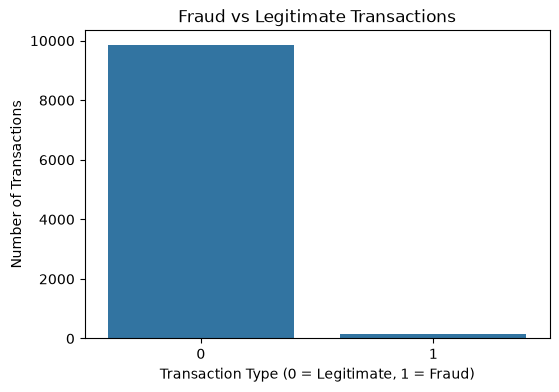

In [9]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="is_fraud")

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Type (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

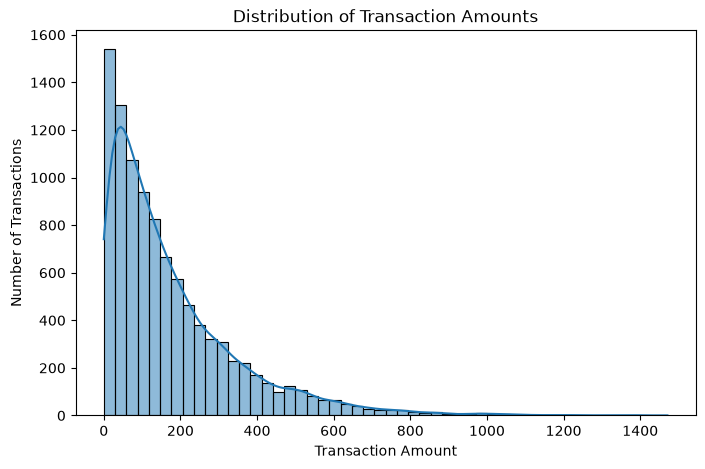

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="amount", bins=50, kde=True)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

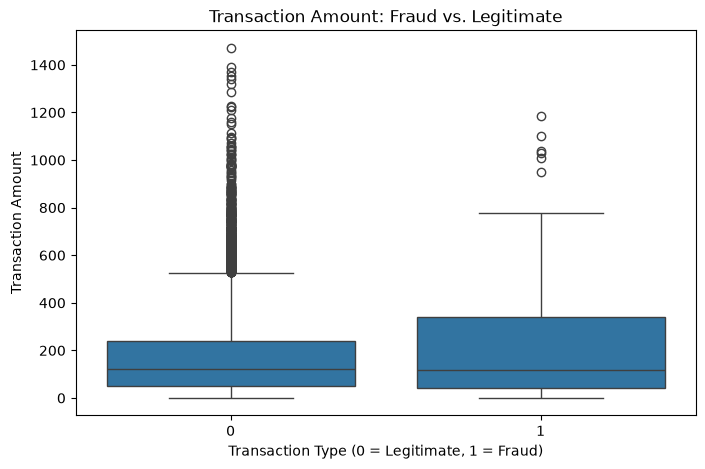

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="is_fraud", y="amount")

plt.title("Transaction Amount: Fraud vs. Legitimate")
plt.xlabel("Transaction Type (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [12]:
fraud_by_category = (
    df.groupby("merchant_category")["is_fraud"]
    .mean()
    .sort_values(ascending=False)
)

print("Fraud Rate by Merchant Category:")
print((fraud_by_category * 100).round(2))

Fraud Rate by Merchant Category:
merchant_category
Grocery        2.01
Food           1.67
Travel         1.46
Electronics    1.25
Clothing       1.17
Name: is_fraud, dtype: float64


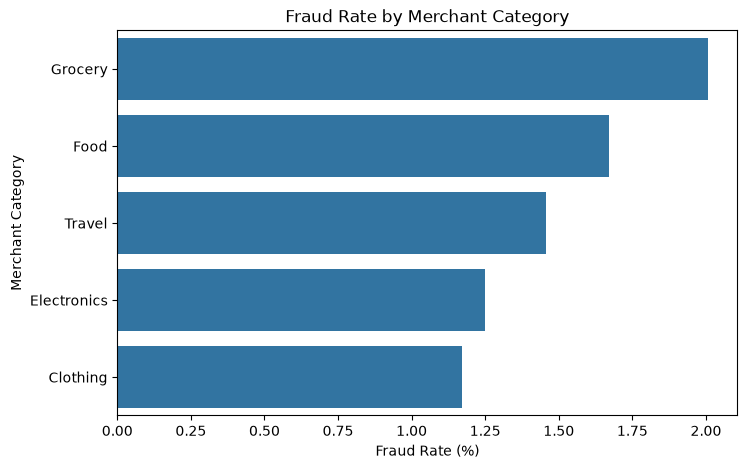

In [13]:
plt.figure(figsize=(8, 5))

fraud_rate_percent = fraud_by_category * 100

sns.barplot(
    x=fraud_rate_percent.values,
    y=fraud_rate_percent.index
)

plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Fraud Rate (%)")
plt.ylabel("Merchant Category")

plt.show()

In [14]:
fraud_by_hour = (
    df.groupby("transaction_hour")["is_fraud"]
    .mean()
    .sort_index()
)

print("Fraud Rate by Transaction Hour:")
print((fraud_by_hour * 100).round(2))

Fraud Rate by Transaction Hour:
transaction_hour
0     8.87
1     8.00
2     5.97
3     6.35
4     0.26
5     0.48
6     0.48
7     0.00
8     0.71
9     0.23
10    0.28
11    0.52
12    0.00
13    0.48
14    0.22
15    0.46
16    0.00
17    0.47
18    0.23
19    0.95
20    0.48
21    0.24
22    0.00
23    0.72
Name: is_fraud, dtype: float64


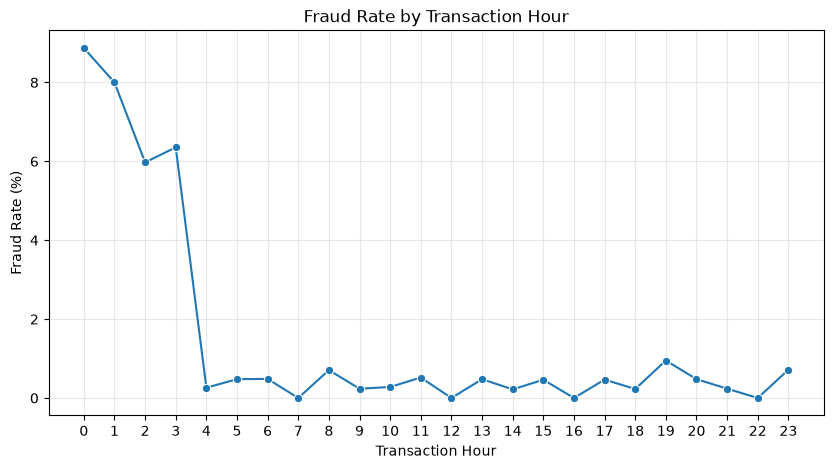

In [15]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=fraud_by_hour.index,
    y=fraud_by_hour.values * 100,
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()

In [16]:
transaction_count_by_hour = (
    df.groupby("transaction_hour")
    .size()
    .sort_index()
)

print("Transaction Count by Hour:")
print(transaction_count_by_hour)

Transaction Count by Hour:
transaction_hour
0     417
1     425
2     385
3     425
4     384
5     419
6     413
7     425
8     424
9     426
10    358
11    385
12    417
13    420
14    458
15    432
16    421
17    429
18    439
19    421
20    419
21    423
22    416
23    419
dtype: int64


In [17]:
hourly_analysis = pd.DataFrame({
    "transaction_count": transaction_count_by_hour,
    "fraud_rate_percent": fraud_by_hour * 100
})

display(hourly_analysis.round(2))

,transaction_count,fraud_rate_percent
transaction_hour,,
0,417,8.87
1,425,8.00
2,385,5.97
3,425,6.35
4,384,0.26
5,419,0.48
6,413,0.48
7,425,0.00
8,424,0.71


In [18]:
top_fraud_hours = hourly_analysis.sort_values(
    "fraud_rate_percent",
    ascending=False
)

print("Hours Ranked by Fraud Rate:")
display(top_fraud_hours.round(2))


Hours Ranked by Fraud Rate:


,transaction_count,fraud_rate_percent
transaction_hour,,
0,417,8.87
1,425,8.00
3,425,6.35
2,385,5.97
19,421,0.95
23,419,0.72
8,424,0.71
11,385,0.52
6,413,0.48


In [19]:
fraud_by_foreign = (
    df.groupby("foreign_transaction")["is_fraud"]
    .mean()
)

print("Fraud Rate by Foreign Transaction:")
print((fraud_by_foreign * 100).round(2))

Fraud Rate by Foreign Transaction:
foreign_transaction
0    0.76
1    8.38
Name: is_fraud, dtype: float64


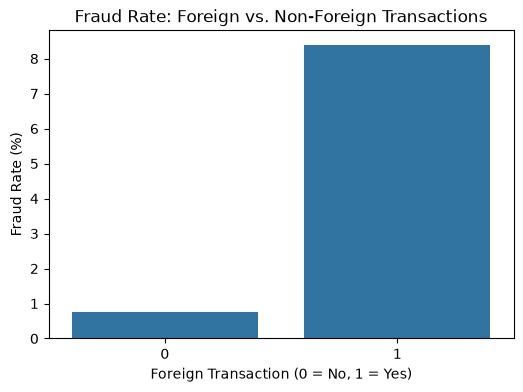

In [20]:
fraud_by_foreign_percent = fraud_by_foreign * 100

plt.figure(figsize=(6, 4))

sns.barplot(
    x=fraud_by_foreign_percent.index,
    y=fraud_by_foreign_percent.values
)

plt.title("Fraud Rate: Foreign vs. Non-Foreign Transactions")
plt.xlabel("Foreign Transaction (0 = No, 1 = Yes)")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [21]:
fraud_by_location = (
    df.groupby("location_mismatch")["is_fraud"]
    .mean()
)

print("Fraud Rate by Location Mismatch:")
print((fraud_by_location * 100).round(2))

Fraud Rate by Location Mismatch:
location_mismatch
0    0.86
1    8.40
Name: is_fraud, dtype: float64


In [22]:
device_trust_summary = (
    df.groupby("is_fraud")["device_trust_score"]
    .agg(["mean", "median", "min", "max"])
)

print("Device Trust Score by Transaction Type:")
display(device_trust_summary.round(2))

Device Trust Score by Transaction Type:


,mean,median,min,max
is_fraud,,,,
0,62.17,62.0,25,99
1,37.87,32.0,25,99


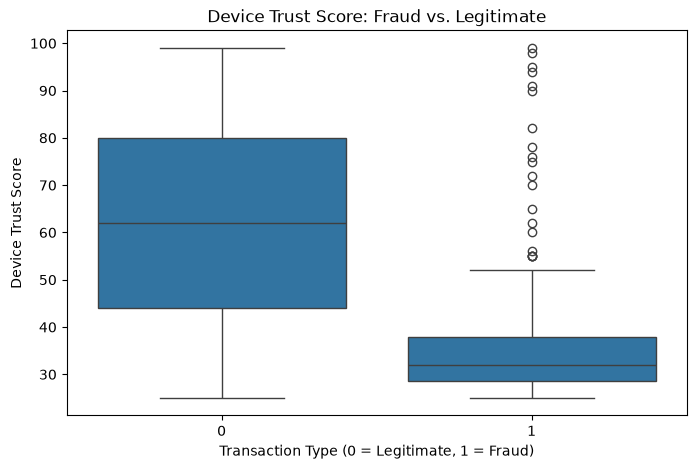

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="device_trust_score"
)

plt.title("Device Trust Score: Fraud vs. Legitimate")
plt.xlabel("Transaction Type (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Device Trust Score")

plt.show()

In [24]:
velocity_summary = (
    df.groupby("is_fraud")["velocity_last_24h"]
    .agg(["mean", "median", "min", "max"])
)

print("Transaction Velocity by Transaction Type:")
display(velocity_summary.round(2))

Transaction Velocity by Transaction Type:


,mean,median,min,max
is_fraud,,,,
0,1.99,2.0,0,9
1,3.21,3.0,0,7


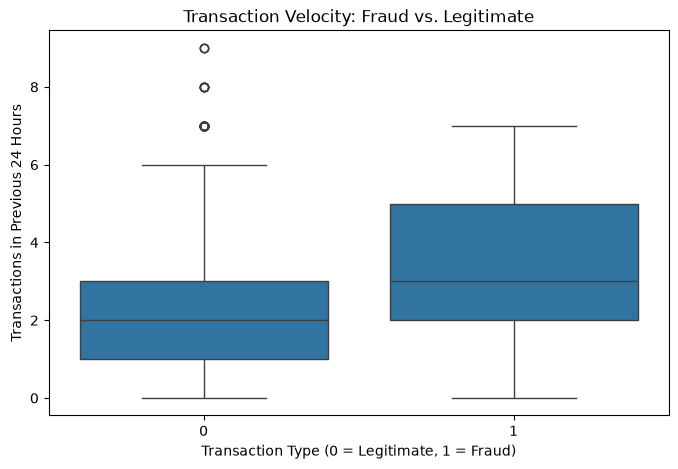

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="velocity_last_24h"
)

plt.title("Transaction Velocity: Fraud vs. Legitimate")
plt.xlabel("Transaction Type (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transactions in Previous 24 Hours")

plt.show()

In [26]:
age_summary = (
    df.groupby("is_fraud")["cardholder_age"]
    .agg(["mean", "median", "min", "max"])
)

print("Cardholder Age by Transaction Type:")
display(age_summary.round(2))

Cardholder Age by Transaction Type:


,mean,median,min,max
is_fraud,,,,
0,43.47,44.0,18,69
1,43.40,44.0,18,69


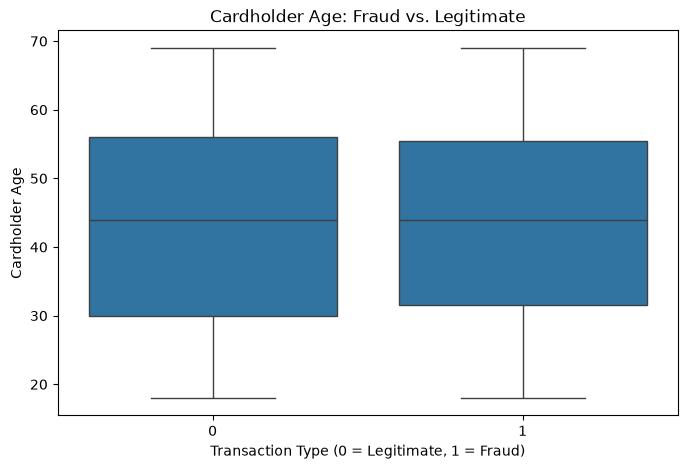

In [27]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="cardholder_age"
)

plt.title("Cardholder Age: Fraud vs. Legitimate")
plt.xlabel("Transaction Type (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Cardholder Age")

plt.show()

In [28]:
amount_summary = (
    df.groupby("is_fraud")["amount"]
    .agg(["mean", "median", "min", "max"])
)

print("Transaction Amount by Transaction Type:")
display(amount_summary.round(2))

Transaction Amount by Transaction Type:


,mean,median,min,max
is_fraud,,,,
0,175.33,122.11,0.00,1471.04
1,216.18,118.94,0.11,1185.07


In [29]:
numeric_columns = [
    "amount",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age",
    "is_fraud"
]

correlation_matrix = df[numeric_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(2))

Correlation Matrix:


,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
amount,1.00,-0.01,0.00,0.00,0.01,-0.00,0.01,0.03
transaction_hour,-0.01,1.00,-0.00,0.00,0.00,-0.00,0.01,-0.14
foreign_transaction,0.00,-0.00,1.00,0.00,0.01,-0.01,0.01,0.19
location_mismatch,0.00,0.00,0.00,1.00,0.00,-0.01,0.01,0.17
device_trust_score,0.01,0.00,0.01,0.00,1.00,-0.00,0.01,-0.14
velocity_last_24h,-0.00,-0.00,-0.01,-0.01,-0.00,1.00,-0.00,0.10
cardholder_age,0.01,0.01,0.01,0.01,0.01,-0.00,1.00,-0.00
is_fraud,0.03,-0.14,0.19,0.17,-0.14,0.10,-0.00,1.00


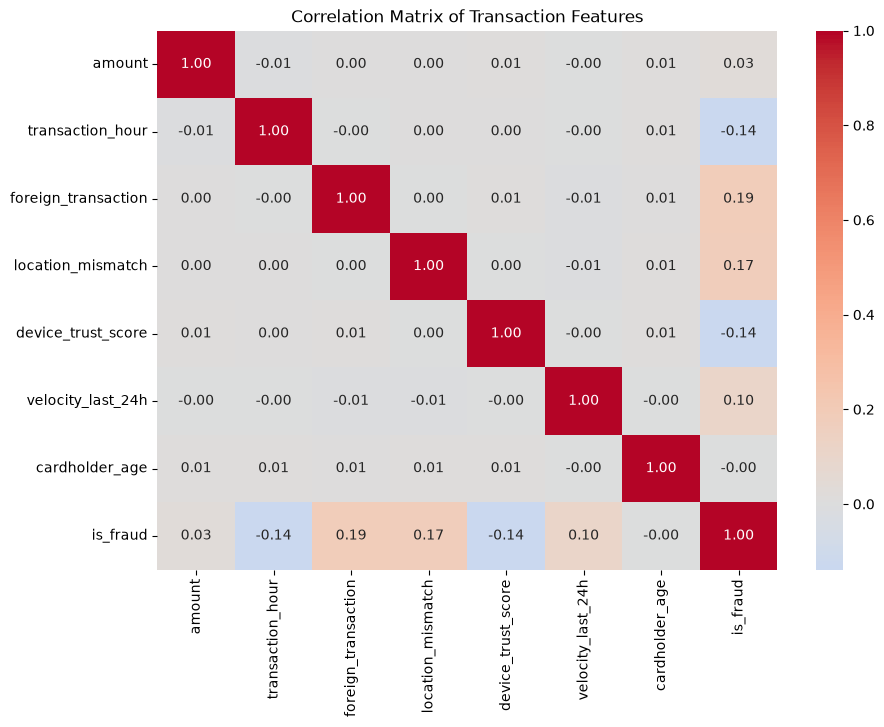

In [30]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Transaction Features")

plt.show()

In [31]:
merchant_counts = df["merchant_category"].value_counts()

print("Transactions by Merchant Category:")
print(merchant_counts)

Transactions by Merchant Category:
merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64


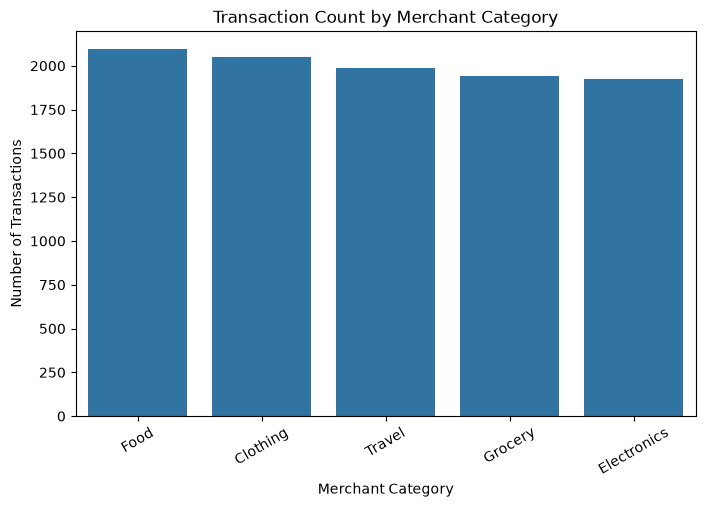

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=merchant_counts.index,
    y=merchant_counts.values
)

plt.title("Transaction Count by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=30)

plt.show()

In [33]:
fraud_count_by_category = (
    df[df["is_fraud"] == 1]
    .groupby("merchant_category")
    .size()
    .sort_values(ascending=False)
)

print("Fraudulent Transactions by Merchant Category:")
print(fraud_count_by_category)

Fraudulent Transactions by Merchant Category:
merchant_category
Grocery        39
Food           35
Travel         29
Clothing       24
Electronics    24
dtype: int64


In [34]:
eda_summary = pd.DataFrame({
    "feature": [
        "Foreign Transaction",
        "Location Mismatch",
        "Device Trust Score",
        "Transaction Velocity",
        "Transaction Hour",
        "Transaction Amount",
        "Cardholder Age"
    ],
    "key_finding": [
        "Fraud rate: 8.38% when foreign vs. 0.76% when non-foreign",
        "Fraud rate: 8.40% when mismatch vs. 0.86% when matched",
        "Mean score: 37.87 for fraud vs. 62.17 for legitimate",
        "Mean velocity: 3.21 for fraud vs. 1.99 for legitimate",
        "Highest fraud rates occur around 00:00–03:00",
        "Mean: 216.18 for fraud vs. 175.33 for legitimate",
        "Mean age is nearly identical: 43.40 vs. 43.47"
    ]
})

display(eda_summary)

,feature,key_finding
0,Foreign Transaction,Fraud rate: 8.38% when foreign vs. 0.76% when ...
1,Location Mismatch,Fraud rate: 8.40% when mismatch vs. 0.86% when...
2,Device Trust Score,Mean score: 37.87 for fraud vs. 62.17 for legi...
3,Transaction Velocity,Mean velocity: 3.21 for fraud vs. 1.99 for leg...
4,Transaction Hour,Highest fraud rates occur around 00:00–03:00
5,Transaction Amount,Mean: 216.18 for fraud vs. 175.33 for legitimate
6,Cardholder Age,Mean age is nearly identical: 43.40 vs. 43.47


# EDA Conclusions

## Key Findings

- The dataset contains **10,000 credit card transactions** and **10 features**.
- There are **151 fraudulent transactions (1.51%)** and **9,849 legitimate transactions (98.49%)**, indicating a significant class imbalance.
- Foreign transactions show a substantially higher observed fraud rate (**8.38%**) compared with non-foreign transactions (**0.76%**).
- Transactions with a location mismatch have a higher observed fraud rate (**8.40%**) compared with transactions without a mismatch (**0.86%**).
- Fraudulent transactions have a lower average device trust score (**37.87**) compared with legitimate transactions (**62.17**).
- Fraudulent transactions have higher average transaction velocity (**3.21**) compared with legitimate transactions (**1.99**).
- The highest observed fraud rates occur during the **00:00–03:00** period.
- Fraudulent transactions have a higher mean transaction amount (**216.18**) than legitimate transactions (**175.33**), although their median amounts are similar.
- Cardholder age shows almost no difference between fraudulent and legitimate transactions (**43.40 vs. 43.47**).
- Merchant categories have relatively balanced transaction volumes, with **Food** having the most transactions and **Electronics** the fewest.
- Grocery has the highest observed fraud rate among merchant categories (**2.01%**).

## Overall Interpretation

The exploratory analysis suggests that several transaction characteristics may be useful for fraud detection, particularly:

- Foreign transaction status
- Location mismatch
- Device trust score
- Transaction velocity
- Transaction hour

These observations represent **associations in this dataset and do not establish causation**.

The next stage of the project will focus on preparing the data for machine learning.

In [35]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [36]:
duplicate_transaction_ids = df["transaction_id"].duplicated().sum()

print("Duplicate transaction IDs:", duplicate_transaction_ids)

Duplicate transaction IDs: 0


In [37]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Feature shape: (10000, 9)
Target shape: (10000,)

Features:
['transaction_id', 'amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']

Target:
is_fraud


In [38]:
X = X.drop(columns=["transaction_id"])

print("Updated feature shape:", X.shape)

print("\nRemaining features:")
print(X.columns.tolist())

Updated feature shape: (10000, 8)

Remaining features:
['amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']


In [39]:
X_encoded = pd.get_dummies(
    X,
    columns=["merchant_category"],
    drop_first=False
)

print("Encoded feature shape:", X_encoded.shape)

print("\nEncoded features:")
print(X_encoded.columns.tolist())

Encoded feature shape: (10000, 12)

Encoded features:
['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']


In [42]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining fraud rate:", round(y_train.mean() * 100, 2), "%")
print("Testing fraud rate:", round(y_test.mean() * 100, 2), "%")

Training feature shape: (8000, 12)
Testing feature shape: (2000, 12)

Training fraud rate: 1.51 %
Testing fraud rate: 1.5 %


In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [45]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 2000


In [46]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 99.3 %


In [47]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1970
           1       0.94      0.57      0.71        30

    accuracy                           0.99      2000
   macro avg       0.97      0.78      0.85      2000
weighted avg       0.99      0.99      0.99      2000



In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1969    1]
 [  13   17]]


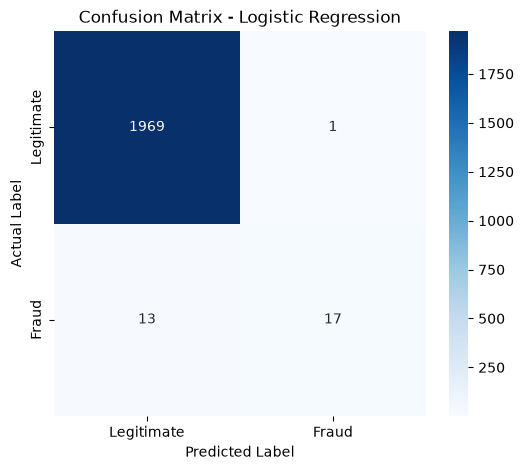

In [49]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [50]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Fraud probabilities generated successfully!")
print("First 10 fraud probabilities:")
print(y_pred_proba[:10])

Fraud probabilities generated successfully!
First 10 fraud probabilities:
[8.10359445e-04 3.79330956e-04 4.54219137e-06 3.00616735e-03
 8.26089688e-05 3.71311783e-03 2.57857658e-08 2.60078268e-03
 1.66594451e-06 2.43592560e-04]


In [51]:
threshold = 0.5

y_pred_threshold = (y_pred_proba >= threshold).astype(int)

print("Threshold:", threshold)
print("Predictions matching original model:", (y_pred_threshold == y_pred).all())
print("Predicted fraud transactions:", y_pred_threshold.sum())

Threshold: 0.5
Predictions matching original model: True
Predicted fraud transactions: 18


In [52]:
threshold = 0.30

y_pred_30 = (y_pred_proba >= threshold).astype(int)

print("Threshold:", threshold)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_30))

Threshold: 0.3

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1970
           1       0.67      0.73      0.70        30

    accuracy                           0.99      2000
   macro avg       0.83      0.86      0.85      2000
weighted avg       0.99      0.99      0.99      2000



In [53]:
cm_30 = confusion_matrix(y_test, y_pred_30)

print("Confusion Matrix at Threshold 0.30:")
print(cm_30)

Confusion Matrix at Threshold 0.30:
[[1959   11]
 [   8   22]]


In [54]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_proba)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.9944


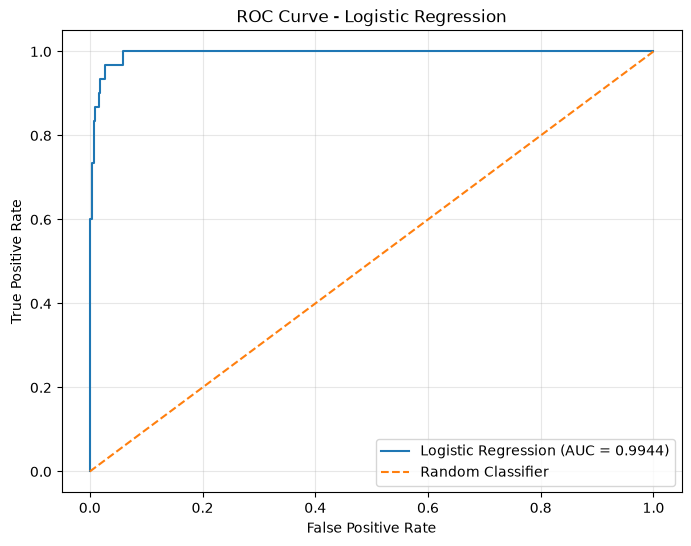

In [55]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

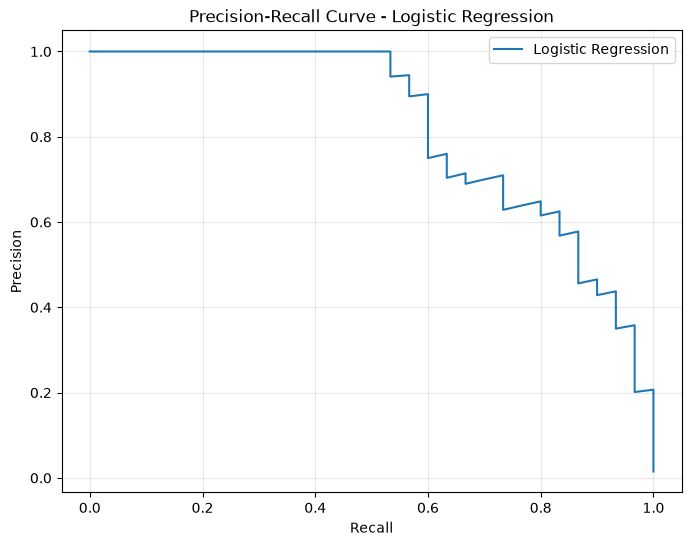

In [56]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_pred_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label="Logistic Regression"
)

plt.title("Precision-Recall Curve - Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [57]:
model_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Fraud Precision (Threshold 0.50)",
        "Fraud Recall (Threshold 0.50)",
        "Fraud F1-Score (Threshold 0.50)",
        "Fraud Precision (Threshold 0.30)",
        "Fraud Recall (Threshold 0.30)",
        "Fraud F1-Score (Threshold 0.30)"
    ],
    "Score": [
        accuracy,
        roc_auc,
        0.94,
        0.57,
        0.71,
        0.67,
        0.73,
        0.70
    ]
})

display(model_results)

,Metric,Score
0,Accuracy,0.993000
1,ROC-AUC,0.994433
2,Fraud Precision (Threshold 0.50),0.940000
3,Fraud Recall (Threshold 0.50),0.570000
4,Fraud F1-Score (Threshold 0.50),0.710000
5,Fraud Precision (Threshold 0.30),0.670000
6,Fraud Recall (Threshold 0.30),0.730000
7,Fraud F1-Score (Threshold 0.30),0.700000


In [58]:
from sklearn.metrics import precision_score, recall_score, f1_score

model_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "ROC-AUC",
        "Fraud Precision (Threshold 0.50)",
        "Fraud Recall (Threshold 0.50)",
        "Fraud F1-Score (Threshold 0.50)",
        "Fraud Precision (Threshold 0.30)",
        "Fraud Recall (Threshold 0.30)",
        "Fraud F1-Score (Threshold 0.30)"
    ],
    "Score": [
        accuracy,
        roc_auc,
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        precision_score(y_test, y_pred_30),
        recall_score(y_test, y_pred_30),
        f1_score(y_test, y_pred_30)
    ]
})

display(model_results.round(4))

,Metric,Score
0,Accuracy,0.9930
1,ROC-AUC,0.9944
2,Fraud Precision (Threshold 0.50),0.9444
3,Fraud Recall (Threshold 0.50),0.5667
4,Fraud F1-Score (Threshold 0.50),0.7083
5,Fraud Precision (Threshold 0.30),0.6667
6,Fraud Recall (Threshold 0.30),0.7333
7,Fraud F1-Score (Threshold 0.30),0.6984


In [59]:
import joblib
import os

model_artifact = {
    "model": model,
    "feature_columns": X_encoded.columns.tolist()
}

model_path = "../../models/logistic_regression_fraud_model.joblib"

joblib.dump(model_artifact, model_path)

print("Model saved successfully!")
print("Saved to:", os.path.abspath(model_path))

Model saved successfully!
Saved to: C:\Users\Siddeswar reddy\AI-ML-Portfolio\models\logistic_regression_fraud_model.joblib


In [60]:
loaded_artifact = joblib.load(model_path)

loaded_model = loaded_artifact["model"]
saved_feature_columns = loaded_artifact["feature_columns"]

print("Model loaded successfully!")
print("Saved feature count:", len(saved_feature_columns))
print("Feature columns:")
print(saved_feature_columns)

loaded_predictions = loaded_model.predict(X_test)

print("\nPredictions generated from loaded model:", len(loaded_predictions))
print(
    "Loaded model predictions match original predictions:",
    (loaded_predictions == y_pred).all()
)

Model loaded successfully!
Saved feature count: 12
Feature columns:
['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']

Predictions generated from loaded model: 2000
Loaded model predictions match original predictions: True
